In [1]:
!pip install pandas numpy matplotlib seaborn sqlalchemy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style("whitegrid")

In [3]:
np.random.seed(42)

data = {
    "Order_ID": np.arange(1, 1001),
        "Customer_ID": np.random.randint(1000, 1100, 1000),
            "Region": np.random.choice(["North", "South", "East", "West"], 1000),
                "Category": np.random.choice(["Electronics", "Clothing", "Grocery", "Furniture"], 1000),
                    "Sales": np.random.randint(100, 5000, 1000),
                        "Quantity": np.random.randint(1, 10, 1000),
                            "Order_Date": pd.date_range(start="2023-01-01", periods=1000, freq="D")
                            }

df = pd.DataFrame(data)
df.head()

,Order_ID,Customer_ID,Region,Category,Sales,Quantity,Order_Date
0,1,1051,South,Electronics,1701,9,2023-01-01
1,2,1092,East,Electronics,2508,8,2023-01-02
2,3,1014,West,Clothing,440,4,2023-01-03
3,4,1071,West,Furniture,2917,1,2023-01-04
4,5,1060,North,Grocery,2596,1,2023-01-05


In [4]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Region,0
Category,0
Sales,0
Quantity,0
Order_Date,0


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [7]:
df.describe()

,Order_ID,Customer_ID,Sales,Quantity,Order_Date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,500.500000,1049.128000,2515.114000,4.991000,2024-05-14 12:00:00
min,1.000000,1000.000000,106.000000,1.000000,2023-01-01 00:00:00
25%,250.750000,1023.000000,1311.500000,3.000000,2023-09-07 18:00:00
50%,500.500000,1050.000000,2444.000000,5.000000,2024-05-14 12:00:00
75%,750.250000,1074.000000,3743.500000,7.000000,2025-01-19 06:00:00
max,1000.000000,1099.000000,4982.000000,9.000000,2025-09-26 00:00:00
std,288.819436,29.573505,1386.219521,2.620264,NaN


In [8]:
df.var(numeric_only=True)

,0
Order_ID,8.341667e+04
Customer_ID,8.745922e+02
Sales,1.921605e+06
Quantity,6.865785e+00


In [9]:
corr = df.corr(numeric_only=True)
corr

,Order_ID,Customer_ID,Sales,Quantity
Order_ID,1.000000,0.001236,0.017894,-0.024651
Customer_ID,0.001236,1.000000,0.029551,0.043302
Sales,0.017894,0.029551,1.000000,0.023460
Quantity,-0.024651,0.043302,0.023460,1.000000


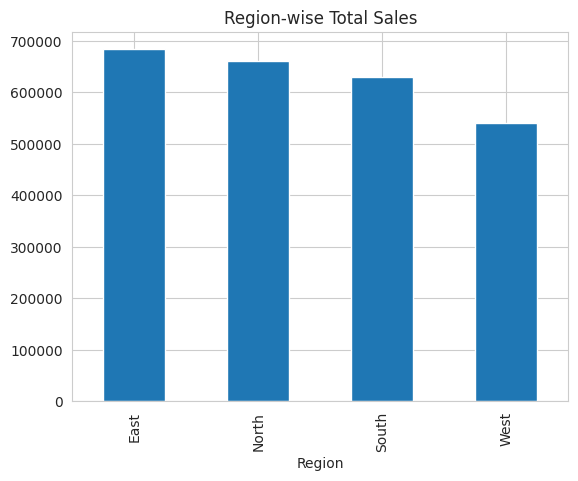

In [10]:
plt.figure()
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Region-wise Total Sales")
plt.show()

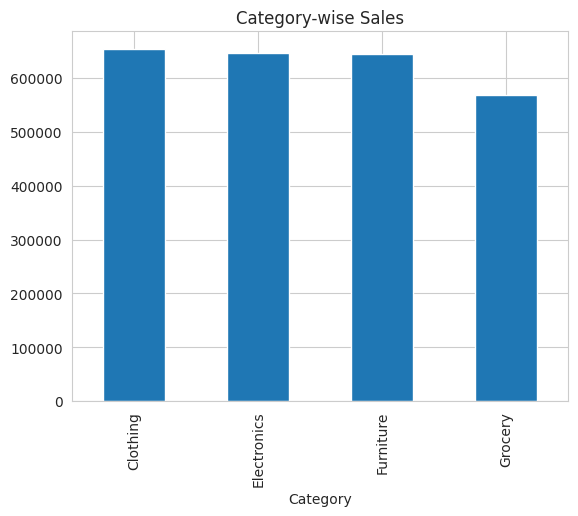

In [11]:
plt.figure()
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Category-wise Sales")
plt.show()

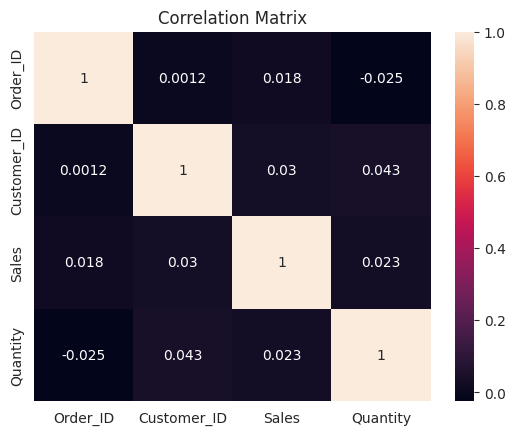

In [12]:
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

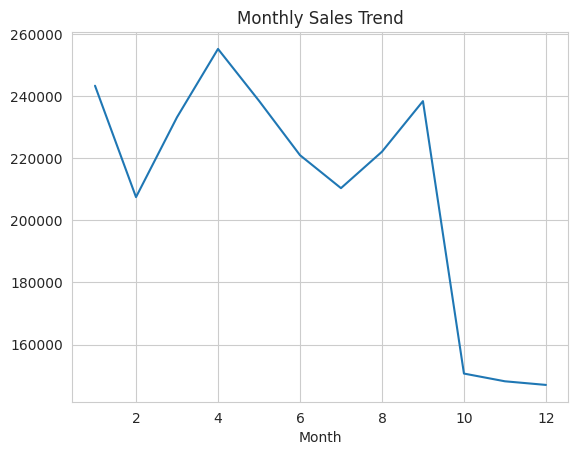

In [13]:
df["Month"] = df["Order_Date"].dt.month

plt.figure()
df.groupby("Month")["Sales"].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

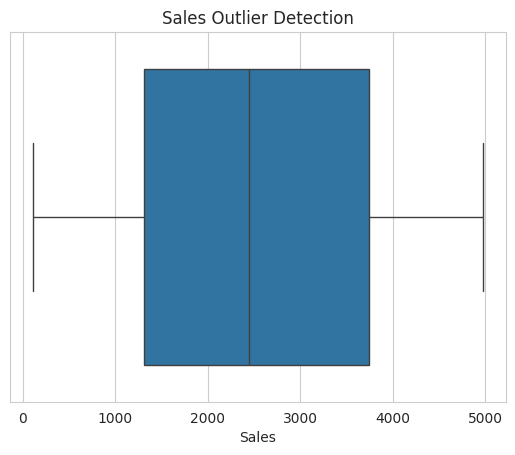

In [14]:
plt.figure()
sns.boxplot(x=df["Sales"])
plt.title("Sales Outlier Detection")
plt.show()

In [15]:
conn = sqlite3.connect("retail.db")
df.to_sql("transactions", conn, if_exists="replace", index=False)

1000

In [16]:
query = """
SELECT Region, SUM(Sales) as Total_Sales
FROM transactions
GROUP BY Region
"""

pd.read_sql(query, conn)

,Region,Total_Sales
0,East,683357
1,North,661160
2,South,629387
3,West,541210
